In [1]:
import numpy as np
import matplotlib.pyplot as plt

Part 1 Least Square Fit with Given Values:

In [2]:
# Data points
X = np.array([1, 2, 3, 4, 5])
Y = np.array([1.2, 2.8, 3.6, 4.5, 5.1])
# Stack the design matrix with a column of ones (for the intercept)
A = np.vstack([X, np.ones(len(X))]).T

print("X:")
print(X)

print("Y:")
print(Y)

print("A:")
print(A)

X:
[1 2 3 4 5]
Y:
[1.2 2.8 3.6 4.5 5.1]
A:
[[1. 1.]
 [2. 1.]
 [3. 1.]
 [4. 1.]
 [5. 1.]]


In [3]:
# Solve using least squares
m, c = np.linalg.lstsq(A, Y, rcond=None)[0]
print(f"Slope: {m}, Intercept: {c}")

Slope: 0.9500000000000001, Intercept: 0.5900000000000001


In [4]:
x1 = np.linspace(min(X), max(X), 100)
y1 = 0.95*x1+0.59

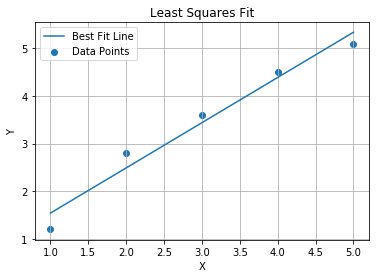

In [5]:
plt.figure()
plt.xlabel("X")
plt.ylabel("Y")
plt.scatter(X, Y, label='Data Points')
plt.plot(x1, y1, label='Best Fit Line')
plt.grid(True)
plt.legend()
plt.title("Least Squares Fit")
plt.show()

Part 2 Least Square Fit with Random Values:

In [6]:
X = np.random.rand(5)
Y = np.random.rand(5)
A = np.vstack([X, np.ones(len(X))]).T

print("X:")
print(X)

print("Y:")
print(Y)

print("A:")
print(A)

X:
[0.56728579 0.16729902 0.23311851 0.66697914 0.61663626]
Y:
[0.59533387 0.9532276  0.40063571 0.39401645 0.04827786]
A:
[[0.56728579 1.        ]
 [0.16729902 1.        ]
 [0.23311851 1.        ]
 [0.66697914 1.        ]
 [0.61663626 1.        ]]


In [7]:
m, c = np.linalg.lstsq(A, Y, rcond=None)[0]
print(f"Slope: {m}, Intercept: {c}")

Slope: -0.8982957466539587, Intercept: 0.8827683058602399


In [8]:
x1 = np.linspace(min(X), max(X), 100)
x1 = np.sort(x1)
y1 = m*x1+c

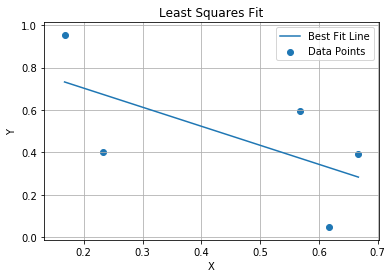

In [9]:
plt.figure()
plt.xlabel("X")
plt.ylabel("Y")
plt.scatter(X, Y, label='Data Points')
plt.plot(x1, y1, label='Best Fit Line')
plt.grid(True)
plt.legend()
plt.title("Least Squares Fit")
plt.show()

With completely randomized data, the best fit line is not able to follow the data very well, as the data itself does not follow any particular trend.

Part 3: Least Square Fit with Generated Data

In [10]:
X = np.arange(0, 1.01, 0.01)
error = np.random.uniform(-1, 1, len(X))
Y = 2*X+2+error
A = np.vstack([X, np.ones(len(X))]).T
m, c = np.linalg.lstsq(A, Y, rcond=None)[0]
print("Original Equation: Y=2X+2")
print(f"Calculated Slope: {m}, Calculated Intercept: {c}")
y1 = m*X+c

Original Equation: Y=2X+2
Calculated Slope: 1.506098890535505, Calculated Intercept: 2.1396153232948585


Residual Error:

In [11]:
rerror = np.abs(Y-y1)
print(f"Residuals: \n{rerror}")
maxrerror = np.max(rerror)
minrerror = np.min(rerror)
maxx = X[np.argmax(rerror)]
minx = X[np.argmin(rerror)]
print(f"Highest Residual Error: \n {maxrerror} at X={maxx}")
print(f"Lowest Residual Error: \n {minrerror} at X={minx}")

Residuals: 
[0.35963113 0.59445405 0.78215421 1.10464173 0.43417567 0.03277069
 0.22641626 0.77012843 0.16382364 0.93039383 0.53715894 0.71746656
 0.12900883 0.31597067 0.87011852 0.65583903 0.81672205 0.79827661
 0.22343672 1.00971604 0.94137728 0.05796887 0.31958064 0.70750468
 0.54338189 0.95318637 0.97761931 0.43638212 0.25191639 0.67937969
 0.00557668 0.02579639 0.2737623  0.61790566 0.7513131  0.67377005
 0.36036159 0.22935207 0.20957757 0.55805106 0.17279822 0.41192802
 0.34328901 0.47845694 0.6228579  0.46384521 0.91157629 0.11943233
 0.56290115 0.75729212 0.48591081 0.77073661 0.42830841 0.74525706
 0.1582831  0.84045557 0.41257476 0.66759396 0.55306359 0.31010287
 0.07820398 0.51787891 0.51365376 0.56512441 0.28113322 1.15701583
 0.60083422 0.21608374 0.44449325 0.42497737 0.01005724 0.47487965
 0.67528721 0.19561649 0.15834475 1.0795566  0.68780182 0.04340244
 0.32128634 0.22205827 0.55388151 0.67464287 0.29618468 0.31170425
 0.71164448 0.23130244 0.01009052 0.11376956 0.686

Plotting:

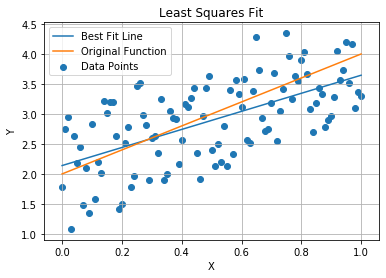

In [12]:
y0=2*X+2
plt.figure()
plt.xlabel("X")
plt.ylabel("Y")
plt.scatter(X, Y, label='Data Points')
plt.plot(X, y1, label='Best Fit Line')
plt.plot(X, y0, label='Original Function')
plt.grid(True)
plt.legend()
plt.title("Least Squares Fit")
plt.show()